# LAPTOP PRICE PREDICTION

## Business Problem

Predict the Price of laptop on the basis of

Context A dataset for 1276 laptop models.

Content, Company Name, Product Name, Laptop Type, Screen Inches, Screen Resolution, CPU Model, RAM Characteristics, Memory, GPU Characteristics, Operating System, Laptop's Weight, Laptop's Price

### Machine Leaning Problem

The task is to build a machine learning model that can predict the price of
laptops based on their features.

## Performance Metric

1. R2 Score

2. Mean Absolute Erro

## Reading data and basic stats

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from google.colab import files
uploaded = files.upload()
df=pd.read_csv("laptop_prices.csv")
df.head()

Saving laptop_prices.csv to laptop_prices.csv


,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


In [4]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'Ram', 'OS', 'Weight',
       'Price_euros', 'Screen', 'ScreenW', 'ScreenH', 'Touchscreen',
       'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_freq', 'CPU_model',
       'PrimaryStorage', 'SecondaryStorage', 'PrimaryStorageType',
       'SecondaryStorageType', 'GPU_company', 'GPU_model'],
      dtype='object')

In [5]:
df.shape

(1275, 23)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   Product               1275 non-null   object 
 2   TypeName              1275 non-null   object 
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   object 
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   object 
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   object 
 12  IPSpanel              1275 non-null   object 
 13  RetinaDisplay         1275 non-null   object 
 14  CPU_company           1275 non-null   object 
 15  CPU_freq             

In [7]:
df.isnull().sum()


,0
Company,0
Product,0
TypeName,0
Inches,0
Ram,0
OS,0
Weight,0
Price_euros,0
Screen,0
ScreenW,0


In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df.head(2)


,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000


## Exploratory Data Analysis and Feature Engineering


<Axes: xlabel='Price_euros', ylabel='Density'>

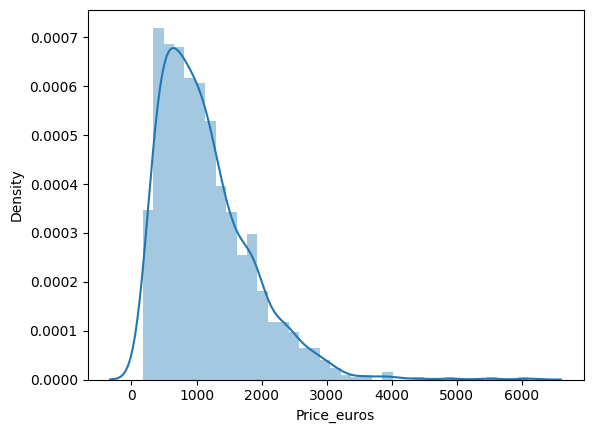

In [10]:
sns.distplot(df["Price_euros"])


<Axes: xlabel='Company'>

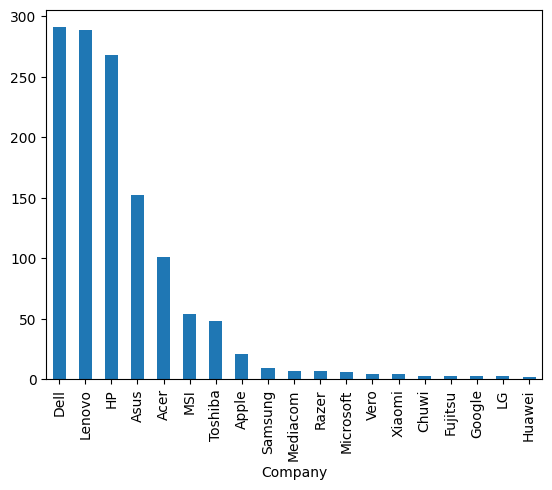

In [11]:
df["Company"].value_counts().plot(kind="bar")


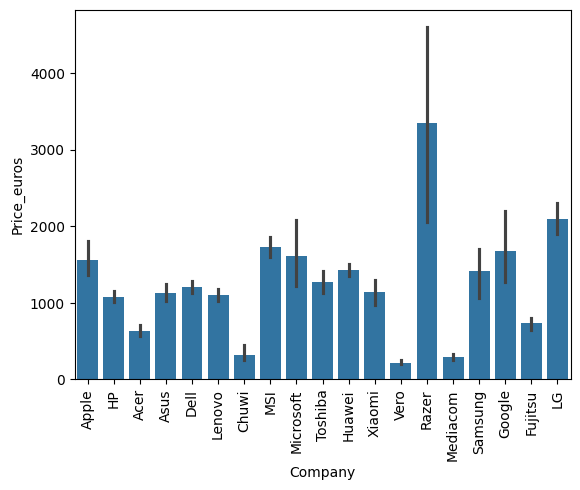

In [12]:
sns.barplot(x=df["Company"],y=df["Price_euros"])
plt.xticks(rotation="vertical")
plt.show()

<Axes: xlabel='TypeName'>

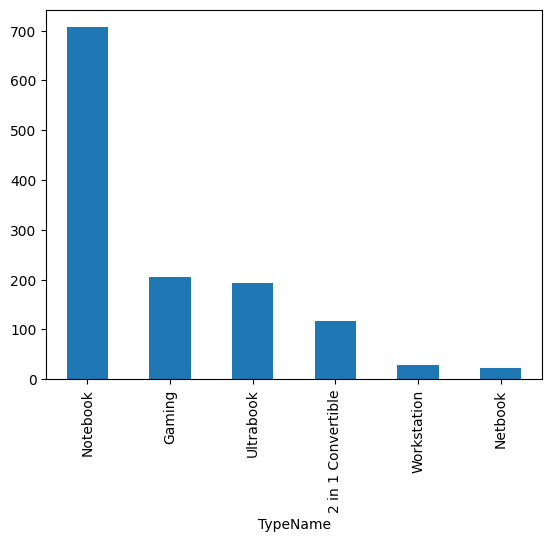

In [13]:

df["TypeName"].value_counts().plot(kind="bar")

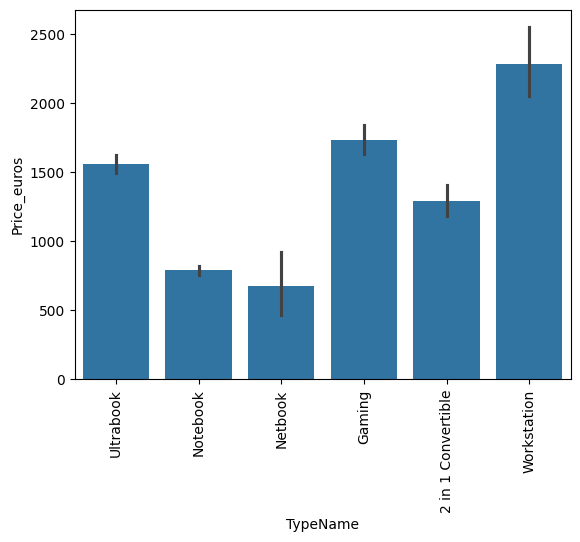

In [14]:
sns.barplot(x=df["TypeName"],y=df["Price_euros"])
plt.xticks(rotation="vertical")
plt.show()

<Axes: ylabel='Density'>

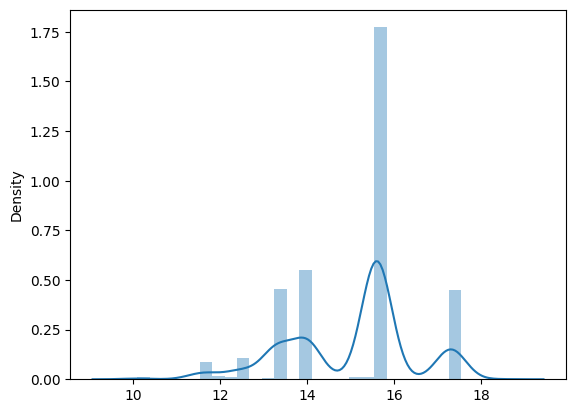

In [15]:
sns.distplot(x=df["Inches"])


<Axes: xlabel='Inches', ylabel='Price_euros'>

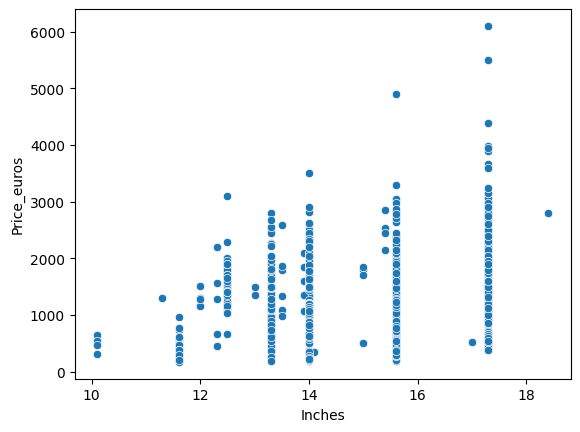

In [16]:
sns.scatterplot(x="Inches",y="Price_euros",data=df)

In [17]:
df["Screen"].value_counts()

,count
Screen,
Full HD,835
Standard,369
4K Ultra HD,43
Quad HD+,28


In [18]:
df["Touchscreen"]=df["Screen"].apply(lambda x:1 if "Touchscreen" in x else 0)

In [19]:
df.head()


,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


<Axes: xlabel='Touchscreen'>

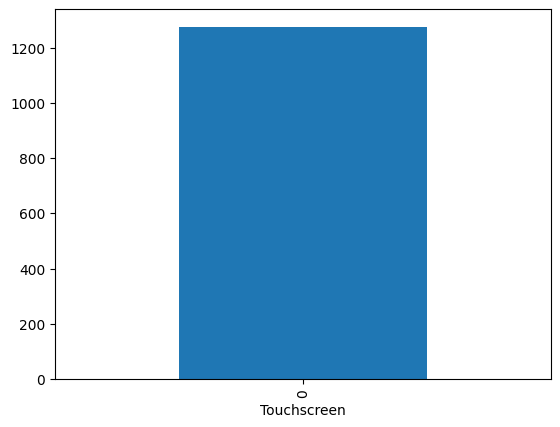

In [20]:
df["Touchscreen"].value_counts().plot(kind="bar")

In [21]:
df["Standard"]=df["Screen"].apply(lambda x:1 if "Standard" in x else 0)

In [22]:
df.head()


,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model,Standard
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640,1
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000,1
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620,0
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455,1
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650,1


<Axes: xlabel='Standard', ylabel='Price_euros'>

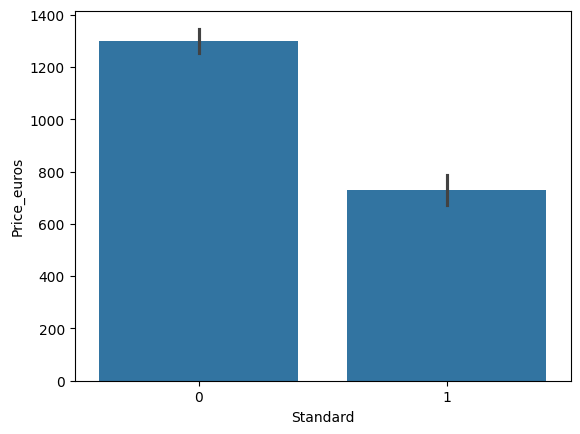

In [23]:
sns.barplot(x=df["Standard"],y=df["Price_euros"])

In [24]:
 df["Screen"].str.split("x")

,Screen
0,[Standard]
1,[Standard]
2,[Full HD]
3,[Standard]
4,[Standard]
...,...
1270,[Full HD]
1271,[Quad HD+]
1272,[Standard]
1273,[Standard]


In [25]:
temp= df["Screen"].str.split("x",n=1,expand=True)
df["X_res"]=temp[0]
df["Y_res"]=temp[0]
df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model,Standard,X_res,Y_res
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640,1,Standard,Standard
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000,1,Standard,Standard
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620,0,Full HD,Full HD
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Core i7,512,0,SSD,No,AMD,Radeon Pro 455,1,Standard,Standard
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650,1,Standard,Standard


In [26]:
df['X_res'] = df['X_res'].str.replace(',','') \
                          .str.findall(r'(\d+\.?\d+)') \
                          .apply(lambda x: x[0] if len(x) > 0 else None)

In [27]:

df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model,Standard,X_res,Y_res
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640,1,None,Standard
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000,1,None,Standard
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620,0,None,Full HD
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Core i7,512,0,SSD,No,AMD,Radeon Pro 455,1,None,Standard
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650,1,None,Standard


In [28]:
df.select_dtypes(include='number').corr()['Price_euros']

,Price_euros
Inches,0.066608
Ram,0.740287
Weight,0.211883
Price_euros,1.000000
ScreenW,0.552491
ScreenH,0.548529
Touchscreen,NaN
CPU_freq,0.428847
PrimaryStorage,-0.124775
SecondaryStorage,0.291207


In [29]:
df.drop(columns=["Screen","X_res","Y_res","Inches"],
        inplace=True,
        errors="ignore")

In [30]:
df.head()


,Company,Product,TypeName,Ram,OS,Weight,Price_euros,ScreenW,ScreenH,Touchscreen,...,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model,Standard
0,Apple,MacBook Pro,Ultrabook,8,macOS,1.37,1339.69,2560,1600,0,...,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640,1
1,Apple,Macbook Air,Ultrabook,8,macOS,1.34,898.94,1440,900,0,...,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000,1
2,HP,250 G6,Notebook,8,No OS,1.86,575.00,1920,1080,0,...,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620,0
3,Apple,MacBook Pro,Ultrabook,16,macOS,1.83,2537.45,2880,1800,0,...,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455,1
4,Apple,MacBook Pro,Ultrabook,8,macOS,1.37,1803.60,2560,1600,0,...,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650,1


In [31]:
df["CPU_model"].value_counts()

,count
CPU_model,
Core i5 7200U,193
Core i7 7700HQ,147
Core i7 7500U,133
Core i3 6006U,81
Core i7 8550U,73
...,...
Core M 6Y54,1
Cortex A72&A53,1
E-Series 9000,1


In [32]:
df.head()


,Company,Product,TypeName,Ram,OS,Weight,Price_euros,ScreenW,ScreenH,Touchscreen,...,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model,Standard
0,Apple,MacBook Pro,Ultrabook,8,macOS,1.37,1339.69,2560,1600,0,...,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640,1
1,Apple,Macbook Air,Ultrabook,8,macOS,1.34,898.94,1440,900,0,...,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000,1
2,HP,250 G6,Notebook,8,No OS,1.86,575.00,1920,1080,0,...,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620,0
3,Apple,MacBook Pro,Ultrabook,16,macOS,1.83,2537.45,2880,1800,0,...,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455,1
4,Apple,MacBook Pro,Ultrabook,8,macOS,1.37,1803.60,2560,1600,0,...,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650,1


In [33]:
df['Cpu Name'] = df['CPU_model'].apply(lambda x:" ".join(x.split()[0:3]))


In [34]:
df.head()


,Company,Product,TypeName,Ram,OS,Weight,Price_euros,ScreenW,ScreenH,Touchscreen,...,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model,Standard,Cpu Name
0,Apple,MacBook Pro,Ultrabook,8,macOS,1.37,1339.69,2560,1600,0,...,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640,1,Core i5
1,Apple,Macbook Air,Ultrabook,8,macOS,1.34,898.94,1440,900,0,...,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000,1,Core i5
2,HP,250 G6,Notebook,8,No OS,1.86,575.00,1920,1080,0,...,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620,0,Core i5 7200U
3,Apple,MacBook Pro,Ultrabook,16,macOS,1.83,2537.45,2880,1800,0,...,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455,1,Core i7
4,Apple,MacBook Pro,Ultrabook,8,macOS,1.37,1803.60,2560,1600,0,...,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650,1,Core i5


In [35]:
def fetch_processor(text):
    text = str(text)   # safety

    if 'i7' in text:
        return 'Core i7'
    elif 'i5' in text:
        return 'Core i5'
    elif 'i3' in text:
        return 'Core i3'
    elif 'Ryzen 7' in text:
        return 'Ryzen 7'
    elif 'Ryzen 5' in text:
        return 'Ryzen 5'
    elif 'Ryzen 3' in text:
        return 'Ryzen 3'
    elif 'AMD' in text:
        return 'AMD Processor'
    else:
        return 'Other'

In [36]:
df['Processor_Type'] = df['CPU_model'].apply(fetch_processor)

<Axes: xlabel='Processor_Type'>

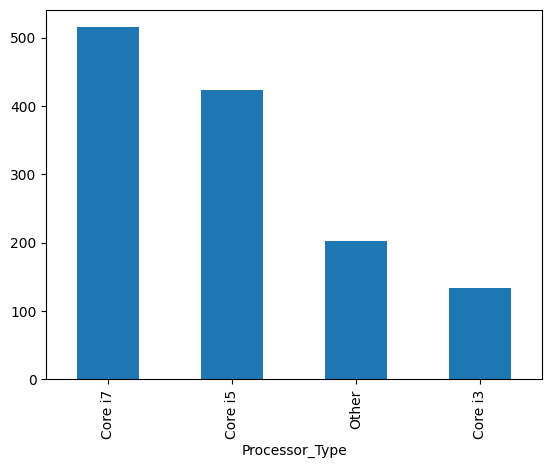

In [37]:
df['Processor_Type'].value_counts().plot(kind='bar')

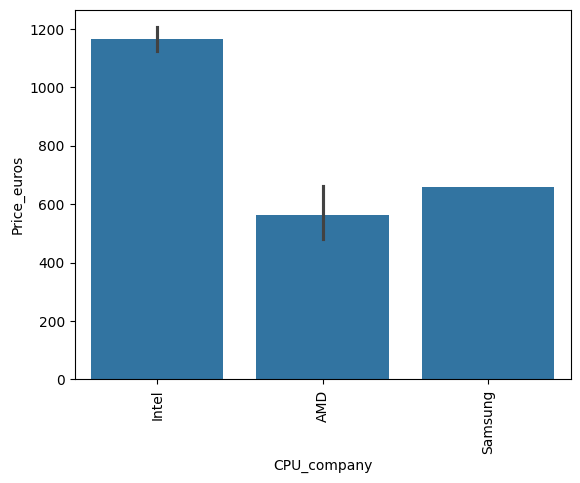

In [38]:
sns.barplot(x=df['CPU_company'],y=df['Price_euros'])
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='Ram'>

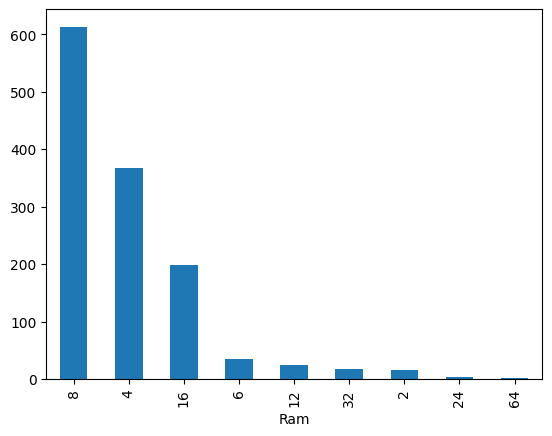

In [39]:

df['Ram'].value_counts().plot(kind='bar')

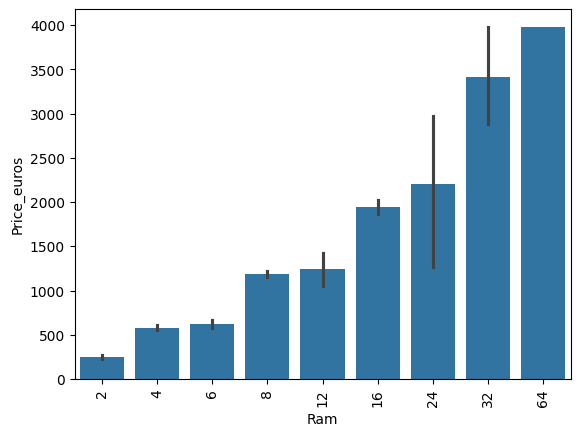

In [40]:
sns.barplot(x=df['Ram'],y=df['Price_euros'])
plt.xticks(rotation='vertical')
plt.show()

In [41]:

df['PrimaryStorage'].value_counts()

,count
PrimaryStorage,
256,508
1024,240
128,175
512,136
500,124
32,43
2048,16
64,15
16,10


In [42]:
df['PrimaryStorage'] = pd.to_numeric(df['PrimaryStorage'], errors='coerce').fillna(0)
df['SecondaryStorage'] = pd.to_numeric(df['SecondaryStorage'], errors='coerce').fillna(0)

# Create storage type columns

df["HDD"] = 0
df["SSD"] = 0
df["Hybrid"] = 0
df["Flash_Storage"] = 0

# Layer 1 (Primary Storage)
df.loc[df['PrimaryStorageType'] == 'HDD', 'HDD'] += df['PrimaryStorage']
df.loc[df['PrimaryStorageType'] == 'SSD', 'SSD'] += df['PrimaryStorage']
df.loc[df['PrimaryStorageType'] == 'Hybrid', 'Hybrid'] += df['PrimaryStorage']
df.loc[df['PrimaryStorageType'] == 'Flash Storage', 'Flash_Storage'] += df['PrimaryStorage']

# Layer 2 (Secondary Storage)
df.loc[df['SecondaryStorageType'] == 'HDD', 'HDD'] += df['SecondaryStorage']
df.loc[df['SecondaryStorageType'] == 'SSD', 'SSD'] += df['SecondaryStorage']
df.loc[df['SecondaryStorageType'] == 'Hybrid', 'Hybrid'] += df['SecondaryStorage']
df.loc[df['SecondaryStorageType'] == 'Flash Storage', 'Flash_Storage'] += df['SecondaryStorage']

In [43]:
df.head()

,Company,Product,TypeName,Ram,OS,Weight,Price_euros,ScreenW,ScreenH,Touchscreen,...,SecondaryStorageType,GPU_company,GPU_model,Standard,Cpu Name,Processor_Type,HDD,SSD,Hybrid,Flash_Storage
0,Apple,MacBook Pro,Ultrabook,8,macOS,1.37,1339.69,2560,1600,0,...,No,Intel,Iris Plus Graphics 640,1,Core i5,Core i5,0,128,0,0
1,Apple,Macbook Air,Ultrabook,8,macOS,1.34,898.94,1440,900,0,...,No,Intel,HD Graphics 6000,1,Core i5,Core i5,0,0,0,128
2,HP,250 G6,Notebook,8,No OS,1.86,575.00,1920,1080,0,...,No,Intel,HD Graphics 620,0,Core i5 7200U,Core i5,0,256,0,0
3,Apple,MacBook Pro,Ultrabook,16,macOS,1.83,2537.45,2880,1800,0,...,No,AMD,Radeon Pro 455,1,Core i7,Core i7,0,512,0,0
4,Apple,MacBook Pro,Ultrabook,8,macOS,1.37,1803.60,2560,1600,0,...,No,Intel,Iris Plus Graphics 650,1,Core i5,Core i5,0,256,0,0


In [44]:
df.drop(columns=['PrimaryStorage'],inplace=True)

In [45]:
df.corr(numeric_only=True)['Price_euros']

,Price_euros
Ram,0.740287
Weight,0.211883
Price_euros,1.000000
ScreenW,0.552491
ScreenH,0.548529
Touchscreen,NaN
CPU_freq,0.428847
SecondaryStorage,0.291207
Standard,-0.368662
HDD,-0.096599


In [46]:
df.drop(columns=['Hybrid','Flash_Storage'],inplace=True)

In [47]:
df.head()

,Company,Product,TypeName,Ram,OS,Weight,Price_euros,ScreenW,ScreenH,Touchscreen,...,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model,Standard,Cpu Name,Processor_Type,HDD,SSD
0,Apple,MacBook Pro,Ultrabook,8,macOS,1.37,1339.69,2560,1600,0,...,0,SSD,No,Intel,Iris Plus Graphics 640,1,Core i5,Core i5,0,128
1,Apple,Macbook Air,Ultrabook,8,macOS,1.34,898.94,1440,900,0,...,0,Flash Storage,No,Intel,HD Graphics 6000,1,Core i5,Core i5,0,0
2,HP,250 G6,Notebook,8,No OS,1.86,575.00,1920,1080,0,...,0,SSD,No,Intel,HD Graphics 620,0,Core i5 7200U,Core i5,0,256
3,Apple,MacBook Pro,Ultrabook,16,macOS,1.83,2537.45,2880,1800,0,...,0,SSD,No,AMD,Radeon Pro 455,1,Core i7,Core i7,0,512
4,Apple,MacBook Pro,Ultrabook,8,macOS,1.37,1803.60,2560,1600,0,...,0,SSD,No,Intel,Iris Plus Graphics 650,1,Core i5,Core i5,0,256


In [48]:

df['GPU_company'].value_counts()

,count
GPU_company,
Intel,704
Nvidia,396
AMD,174
ARM,1


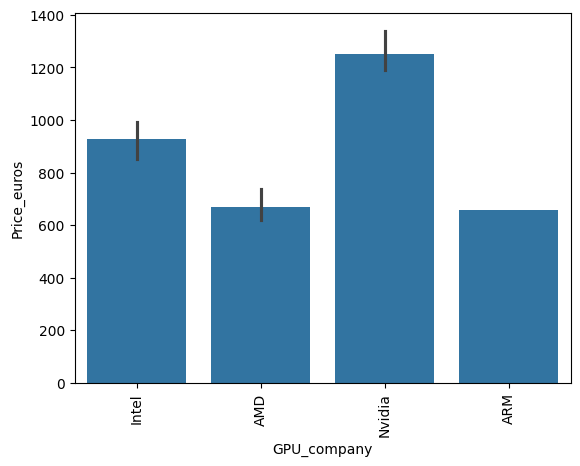

In [49]:
sns.barplot(x=df['GPU_company'],y=df['Price_euros'],estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

In [50]:
df['GPU_company'] = df['GPU_model'].apply(lambda x:x.split()[0])

In [51]:
df.head()


,Company,Product,TypeName,Ram,OS,Weight,Price_euros,ScreenW,ScreenH,Touchscreen,...,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model,Standard,Cpu Name,Processor_Type,HDD,SSD
0,Apple,MacBook Pro,Ultrabook,8,macOS,1.37,1339.69,2560,1600,0,...,0,SSD,No,Iris,Iris Plus Graphics 640,1,Core i5,Core i5,0,128
1,Apple,Macbook Air,Ultrabook,8,macOS,1.34,898.94,1440,900,0,...,0,Flash Storage,No,HD,HD Graphics 6000,1,Core i5,Core i5,0,0
2,HP,250 G6,Notebook,8,No OS,1.86,575.00,1920,1080,0,...,0,SSD,No,HD,HD Graphics 620,0,Core i5 7200U,Core i5,0,256
3,Apple,MacBook Pro,Ultrabook,16,macOS,1.83,2537.45,2880,1800,0,...,0,SSD,No,Radeon,Radeon Pro 455,1,Core i7,Core i7,0,512
4,Apple,MacBook Pro,Ultrabook,8,macOS,1.37,1803.60,2560,1600,0,...,0,SSD,No,Iris,Iris Plus Graphics 650,1,Core i5,Core i5,0,256


In [52]:

df['GPU_company'].value_counts()

,count
GPU_company,
HD,621
GeForce,364
Radeon,167
UHD,68
Quadro,31
Iris,14
FirePro,5
R4,1
R17M-M1-70,1


In [53]:
df = df[df['GPU_company'] != 'ARM']

In [54]:

df['GPU_company'].value_counts()

,count
GPU_company,
HD,621
GeForce,364
Radeon,167
UHD,68
Quadro,31
Iris,14
FirePro,5
R4,1
R17M-M1-70,1


In [55]:
df.drop(columns=['GPU_company'],inplace=True)

In [56]:

df.head()

,Company,Product,TypeName,Ram,OS,Weight,Price_euros,ScreenW,ScreenH,Touchscreen,...,CPU_model,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_model,Standard,Cpu Name,Processor_Type,HDD,SSD
0,Apple,MacBook Pro,Ultrabook,8,macOS,1.37,1339.69,2560,1600,0,...,Core i5,0,SSD,No,Iris Plus Graphics 640,1,Core i5,Core i5,0,128
1,Apple,Macbook Air,Ultrabook,8,macOS,1.34,898.94,1440,900,0,...,Core i5,0,Flash Storage,No,HD Graphics 6000,1,Core i5,Core i5,0,0
2,HP,250 G6,Notebook,8,No OS,1.86,575.00,1920,1080,0,...,Core i5 7200U,0,SSD,No,HD Graphics 620,0,Core i5 7200U,Core i5,0,256
3,Apple,MacBook Pro,Ultrabook,16,macOS,1.83,2537.45,2880,1800,0,...,Core i7,0,SSD,No,Radeon Pro 455,1,Core i7,Core i7,0,512
4,Apple,MacBook Pro,Ultrabook,8,macOS,1.37,1803.60,2560,1600,0,...,Core i5,0,SSD,No,Iris Plus Graphics 650,1,Core i5,Core i5,0,256


In [57]:
df['OS'].value_counts()

,count
OS,
Windows 10,1048
No OS,66
Linux,58
Windows 7,45
Chrome OS,27
macOS,13
Mac OS X,8
Windows 10 S,8
Android,2


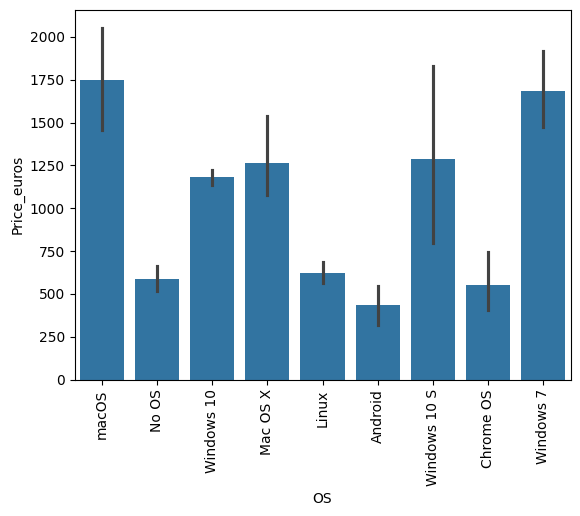

In [58]:
sns.barplot(x=df['OS'],y=df['Price_euros'])
plt.xticks(rotation='vertical')
plt.show()

In [59]:
def cat_os(inp):
    if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'
    elif inp == 'macOS' or inp == 'Mac OS X':
        return 'Mac'
    else:
        return 'Others/No OS/Linux'

In [60]:
df['os'] = df['OS'].apply(cat_os)

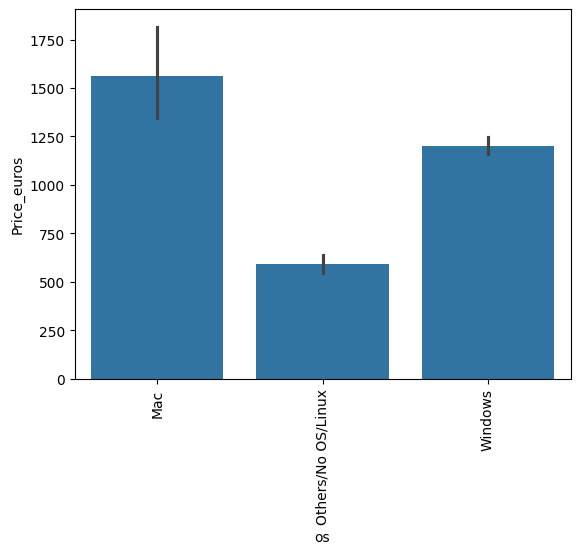

In [61]:
sns.barplot(x=df['os'],y=df['Price_euros'])
plt.xticks(rotation='vertical')
plt.show()

In [62]:
df.drop(columns=['OS'],inplace=True)

In [63]:

df.head()

,Company,Product,TypeName,Ram,Weight,Price_euros,ScreenW,ScreenH,Touchscreen,IPSpanel,...,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_model,Standard,Cpu Name,Processor_Type,HDD,SSD,os
0,Apple,MacBook Pro,Ultrabook,8,1.37,1339.69,2560,1600,0,Yes,...,0,SSD,No,Iris Plus Graphics 640,1,Core i5,Core i5,0,128,Mac
1,Apple,Macbook Air,Ultrabook,8,1.34,898.94,1440,900,0,No,...,0,Flash Storage,No,HD Graphics 6000,1,Core i5,Core i5,0,0,Mac
2,HP,250 G6,Notebook,8,1.86,575.00,1920,1080,0,No,...,0,SSD,No,HD Graphics 620,0,Core i5 7200U,Core i5,0,256,Others/No OS/Linux
3,Apple,MacBook Pro,Ultrabook,16,1.83,2537.45,2880,1800,0,Yes,...,0,SSD,No,Radeon Pro 455,1,Core i7,Core i7,0,512,Mac
4,Apple,MacBook Pro,Ultrabook,8,1.37,1803.60,2560,1600,0,Yes,...,0,SSD,No,Iris Plus Graphics 650,1,Core i5,Core i5,0,256,Mac


<Axes: xlabel='Weight', ylabel='Density'>

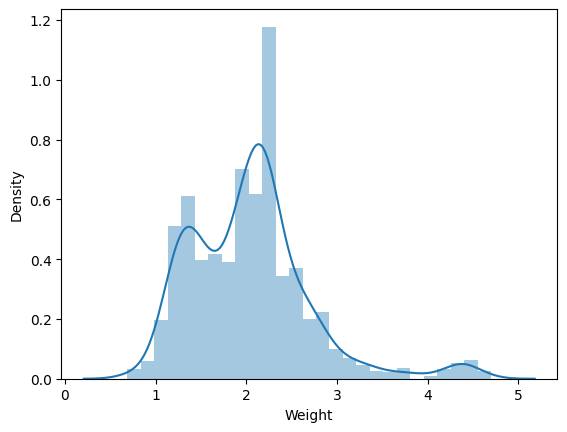

In [64]:
sns.distplot(df['Weight'])

<Axes: xlabel='Weight', ylabel='Price_euros'>

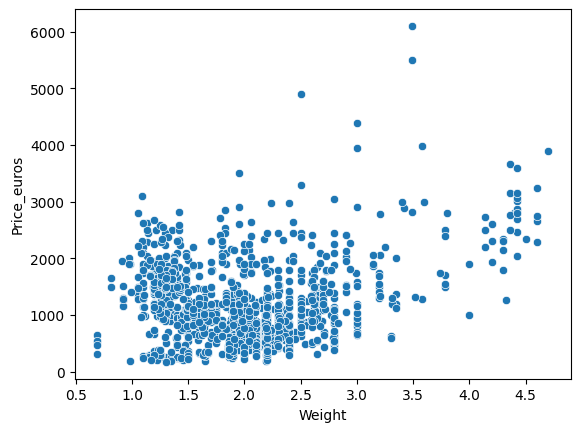

In [65]:

sns.scatterplot(x=df['Weight'],y=df['Price_euros'])

In [66]:
df.corr(numeric_only=True)['Price_euros']

,Price_euros
Ram,0.740287
Weight,0.211883
Price_euros,1.000000
ScreenW,0.552491
ScreenH,0.548529
Touchscreen,NaN
CPU_freq,0.428847
SecondaryStorage,0.291207
Standard,-0.368662
HDD,-0.096599


In [67]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   Product               1275 non-null   object 
 2   TypeName              1275 non-null   object 
 3   Ram                   1275 non-null   int64  
 4   Weight                1275 non-null   float64
 5   Price_euros           1275 non-null   float64
 6   ScreenW               1275 non-null   int64  
 7   ScreenH               1275 non-null   int64  
 8   Touchscreen           1275 non-null   int64  
 9   IPSpanel              1275 non-null   object 
 10  RetinaDisplay         1275 non-null   object 
 11  CPU_company           1275 non-null   object 
 12  CPU_freq              1275 non-null   float64
 13  CPU_model             1275 non-null   object 
 14  SecondaryStorage      1275 non-null   int64  
 15  PrimaryStorageType   

<Axes: >

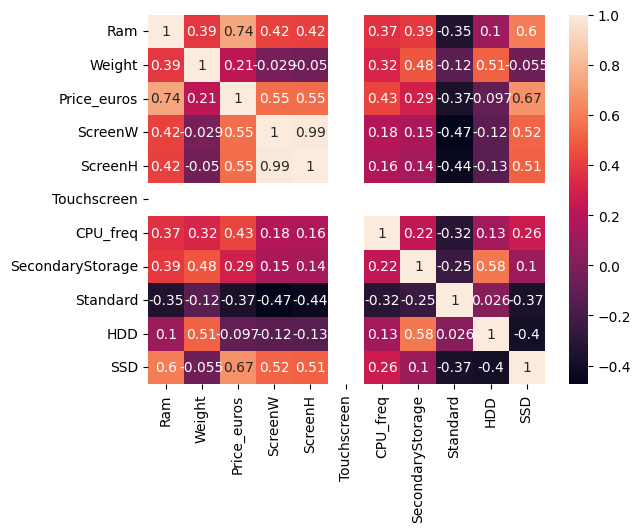

In [68]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

<Axes: xlabel='Price_euros', ylabel='Density'>

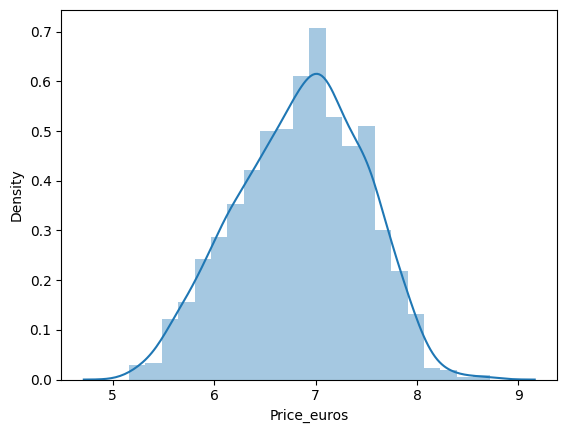

In [69]:
sns.distplot(np.log(df['Price_euros']))

# Model **Selection**

In [70]:
X = df.drop(columns=['Price_euros'])
y = np.log(df['Price_euros'])

In [71]:
X

,Company,Product,TypeName,Ram,Weight,ScreenW,ScreenH,Touchscreen,IPSpanel,RetinaDisplay,...,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_model,Standard,Cpu Name,Processor_Type,HDD,SSD,os
0,Apple,MacBook Pro,Ultrabook,8,1.37,2560,1600,0,Yes,Yes,...,0,SSD,No,Iris Plus Graphics 640,1,Core i5,Core i5,0,128,Mac
1,Apple,Macbook Air,Ultrabook,8,1.34,1440,900,0,No,No,...,0,Flash Storage,No,HD Graphics 6000,1,Core i5,Core i5,0,0,Mac
2,HP,250 G6,Notebook,8,1.86,1920,1080,0,No,No,...,0,SSD,No,HD Graphics 620,0,Core i5 7200U,Core i5,0,256,Others/No OS/Linux
3,Apple,MacBook Pro,Ultrabook,16,1.83,2880,1800,0,Yes,Yes,...,0,SSD,No,Radeon Pro 455,1,Core i7,Core i7,0,512,Mac
4,Apple,MacBook Pro,Ultrabook,8,1.37,2560,1600,0,Yes,Yes,...,0,SSD,No,Iris Plus Graphics 650,1,Core i5,Core i5,0,256,Mac
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1270,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,4,1.80,1920,1080,0,Yes,No,...,0,SSD,No,HD Graphics 520,0,Core i7 6500U,Core i7,0,128,Windows
1271,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,16,1.30,3200,1800,0,Yes,No,...,0,SSD,No,HD Graphics 520,0,Core i7 6500U,Core i7,0,512,Windows
1272,Lenovo,IdeaPad 100S-14IBR,Notebook,2,1.50,1366,768,0,No,No,...,0,Flash Storage,No,HD Graphics,1,Celeron Dual Core,Other,0,0,Windows
1273,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,6,2.19,1366,768,0,No,No,...,0,HDD,No,Radeon R5 M330,1,Core i7 6500U,Core i7,1024,0,Windows


In [72]:
y

,Price_euros
0,7.200194
1,6.801216
2,6.354370
3,7.838915
4,7.497540
...,...
1270,6.458338
1271,7.312553
1272,5.433722
1273,6.638568


In [73]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.15,random_state=2)

In [74]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score,mean_absolute_error

In [75]:

from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Linear **Regression**

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_absolute_error

# Define X and y
X = df.drop('Price_euros', axis=1)
y = df['Price_euros']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Automatically detect categorical columns
categorical_cols = X.select_dtypes(include='object').columns

# Column Transformer
step1 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first',
                              sparse_output=False,
                              handle_unknown='ignore'),
         categorical_cols)
    ],
    remainder='passthrough'
)

# Model
step2 = Lasso(alpha=0.001)

# Pipeline
pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

# Train
pipe.fit(X_train, y_train)

# Predict
y_pred = pipe.predict(X_test)

# Evaluation
print("R2 score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 score: 0.8522556937179987
MAE: 185.5770230651263


# KNN

In [77]:
X = df.drop(columns=['Price_euros'])
y = df['Price_euros']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Detect categorical columns from TRAIN set
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

print("Categorical columns:", categorical_cols)

# Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first',
                              sparse_output=False,
                              handle_unknown='ignore'),
         categorical_cols)
    ],
    remainder='passthrough'
)

# Pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.001))
])

# Fit
pipe.fit(X_train, y_train)

# Predict
y_pred = pipe.predict(X_test)

print("R2 score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

Categorical columns: ['Company', 'Product', 'TypeName', 'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_model', 'PrimaryStorageType', 'SecondaryStorageType', 'GPU_model', 'Cpu Name', 'Processor_Type', 'os']
R2 score: 0.8522556937179987
MAE: 185.5770230651263


# Decision Tree

In [78]:

X = df.drop(columns=['Price_euros'])
y = df['Price_euros']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Detect categorical columns (object + category)
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical columns:", categorical_cols)

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first',
                              sparse_output=False,
                              handle_unknown='ignore'),
         categorical_cols)
    ],
    remainder='passthrough'
)

# Pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.001))
])

# Train
pipe.fit(X_train, y_train)

# Predict
y_pred = pipe.predict(X_test)

print("R2 score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

Categorical columns: ['Company', 'Product', 'TypeName', 'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_model', 'PrimaryStorageType', 'SecondaryStorageType', 'GPU_model', 'Cpu Name', 'Processor_Type', 'os']
R2 score: 0.8522556937179987
MAE: 185.5770230651263



# SVM

In [79]:
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
X = df.drop(columns=['Price_euros'])
y = df['Price_euros']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Encode all non-numeric columns
preprocessor = make_column_transformer(
    (OneHotEncoder(drop='first',
                   handle_unknown='ignore',
                   sparse_output=False),
     X_train.select_dtypes(exclude=['int64','float64']).columns),
    remainder='passthrough'
)

# Pipeline
pipe = make_pipeline(preprocessor, Lasso(alpha=0.001))

# Train
pipe.fit(X_train, y_train)

# Predict
y_pred = pipe.predict(X_test)

print("R2 score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R2 score: 0.8522556937179987
MAE: 185.5770230651263


# Random Forest

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_absolute_error

# Define X and y
X = df.drop(columns=['Price_euros'])
y = df['Price_euros']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Separate categorical & numeric columns properly
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

# Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first',
                              handle_unknown='ignore',
                              sparse_output=False),
         categorical_cols)
    ],
    remainder='passthrough'
)

# Pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.001))
])

# Train
pipe.fit(X_train, y_train)

# Predict
y_pred = pipe.predict(X_test)

print("R2 score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

Categorical: ['Company', 'Product', 'TypeName', 'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_model', 'PrimaryStorageType', 'SecondaryStorageType', 'GPU_model', 'Cpu Name', 'Processor_Type', 'os']
Numeric: ['Ram', 'Weight', 'ScreenW', 'ScreenH', 'Touchscreen', 'CPU_freq', 'SecondaryStorage', 'Standard', 'HDD', 'SSD']
R2 score: 0.8522556937179987
MAE: 185.5770230651263


# ExtraTrees

In [81]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

X = df.drop('Price_euros', axis=1)
y = df['Price_euros']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Automatically detect categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'),
         categorical_cols)
    ],
    remainder='passthrough'
)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.001))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.8522556937179939
MAE: 185.57702306513258



# Stacking

In [82]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

# Automatically detect categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'),
         categorical_cols)
    ],
    remainder='passthrough'
)

estimators = [
    ('rf', RandomForestRegressor(
        n_estimators=350,
        random_state=3,
        max_samples=0.5,
        max_features=0.75,
        max_depth=15
    )),
    ('gbdt', GradientBoostingRegressor(
        n_estimators=100,
        max_features=0.5
    )),
    ('xgb', XGBRegressor(
        n_estimators=25,
        learning_rate=0.3,
        max_depth=5
    ))
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=100)
)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', stack)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))

R2 score: 0.8807406555796508
MAE: 174.1308935941848


# Observations

**Stacking model gives the best R2 score**

R2 score: 0.8801462758309168

MAE: 174.00709412555875

# Exporting the Model

In [84]:
import pickle

pickle.dump(df,open('df.pkl','wb'))
pickle.dump(pipe,open('model.pkl','wb'))